# Question 2: 

fördert anonymität die illegale entsorgung? gibt es in quartieren mit höherer bevölkerungsdichte auch mehr illegal entsorgter abfall

import packages


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

### Access and load data via API (züri wie neu, neighbourhoods, population)

In [2]:
#Access and load the züri wie neu data via API

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
response_zwn = requests.get(url_zwn)
if response_zwn.status_code == 200:
    print("Data züri wie neu loaded sugessfull")
    zwn_gdf = gpd.read_file(response_zwn.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("Data züri wie neu loading failed")

Data züri wie neu loaded sugessfull


In [3]:
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"
response_neighbourhoods = requests.get(url_neighbourhoods)
if response_neighbourhoods.status_code == 200:
    print("Data neighbourhood loaded sugessfull")
    neighbourhoods_gdf = gpd.read_file(response_neighbourhoods.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("Data neighbourhood loading failed")

Data neighbourhood loaded sugessfull


In [4]:

#Access and load the Population data via API

url_population = 'https://data.stadt-zuerich.ch/api/3/action/datastore_search'
parameter_population = {"resource_id":"9f9e2f24-96a7-4542-843c-52d44a904110", "limit":3000}
response_population = requests.get(url_population, params=parameter_population)
if response_population.status_code == 200:
    print("Data Population loaded sugessfull")

    #convert the json response into a dictionary (because the CKAN API returns a new dictionary where the data is in result and record)
    population_dic = response_population.json()["result"]["records"]
    #convert the dictionary into a dataframe
    population_df = pd.DataFrame(population_dic)
else:
    print("Data population loading failed")



Data Population loaded sugessfull


## clean and filter the data

filter population for the newest year and clean and filter the data

In [5]:

## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year (always current year minus 3)
population_df = population_df[population_df["StichtagDatJahr"] == str(current_year-1)].copy()



In [6]:
#clean the data (convert to float, keep important columns)
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})



filter the züri wie neu data for waste and important columns

In [7]:
# Sort the züri wie neu data for waste and filter the columns

zwn_waste_gdf = zwn_gdf[zwn_gdf["service_name"]=="Abfall/Sammelstelle"]
zwn_waste_gdf_filtered = zwn_waste_gdf[["service_request_id", "title", "geometry"]].copy()



filter columns in neighbourhoods file

In [8]:
#clean neighbourhoods file

neighbourhoods_gdf_filtered = neighbourhoods_gdf[["qname", "qnr", "geometry"]]


## join and merge data together

In [18]:

#join the trash points to the neighbourhoods

neighbourhoods_with_waste_df = gpd.sjoin(zwn_waste_gdf_filtered, 
                                          neighbourhoods_gdf_filtered,
                                          how="inner",
                                          predicate="within")

#mask_groupby_neighbourhood = neighbourhoods_with_waste_df.groupby("qname", as_index=False)

neighbourhood_with_waste_df = neighbourhoods_with_waste_df[["qname"]].value_counts()

print(neighbourhood_with_waste_df.head(20))


qname        
Langstrasse      3873
Sihlfeld         3161
Hard             1636
Altstetten       1412
Alt-Wiedikon     1285
Unterstrass      1129
Seebach          1086
Werd              932
Wipkingen         921
Höngg             915
Wollishofen       871
Oerlikon          842
Gewerbeschule     837
Affoltern         785
Enge              699
Albisrieden       648
Hottingen         532
Seefeld           513
Rathaus           491
Hirslanden        477
Name: count, dtype: int64


In [10]:
# merge the population to the neighbourhoods

neighbourhood_with_population_waste_df = pd.merge(left=neighbourhood_with_waste_df, 
                                        right=population_df,
                                        left_on="qname",
                                        right_on="qname")
neighbourhood_with_population_waste_df = neighbourhood_with_population_waste_df.sort_values(by="population", ascending=True)
neighbourhood_with_population_waste_df = neighbourhood_with_population_waste_df.set_index("qname")


In [11]:
# merge the population and waste to the geometry and calculate the pop density

neighbourhood_with_popdensity_waste_gdf = pd.merge(left=neighbourhoods_gdf_filtered, 
                                        right=neighbourhood_with_population_waste_df,
                                        left_on="qname",
                                        right_on="qname")

neighbourhood_with_popdensity_waste_gdf["population_density"] = neighbourhood_with_popdensity_waste_gdf["population"]/neighbourhood_with_popdensity_waste_gdf.geometry.area
neighbourhood_with_popdensity_waste_gdf["waste_density"] = neighbourhood_with_popdensity_waste_gdf["count"]/neighbourhood_with_popdensity_waste_gdf.geometry.area

neighbourhood_with_popdensity_waste_gdf = neighbourhood_with_popdensity_waste_gdf.sort_values(by= "population_density", ascending=True)


## plot data

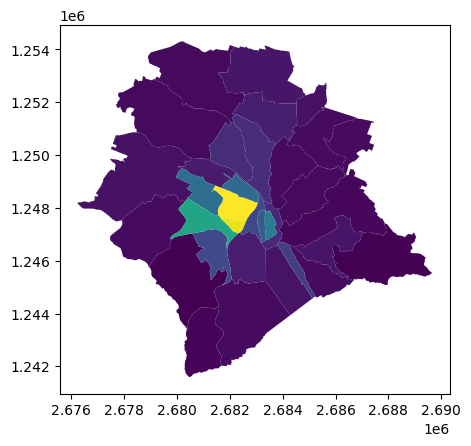

In [12]:
fig, ax = plt.subplots()
neighbourhood_with_popdensity_waste_gdf.plot(ax=ax, column= "waste_density")

plt.show()

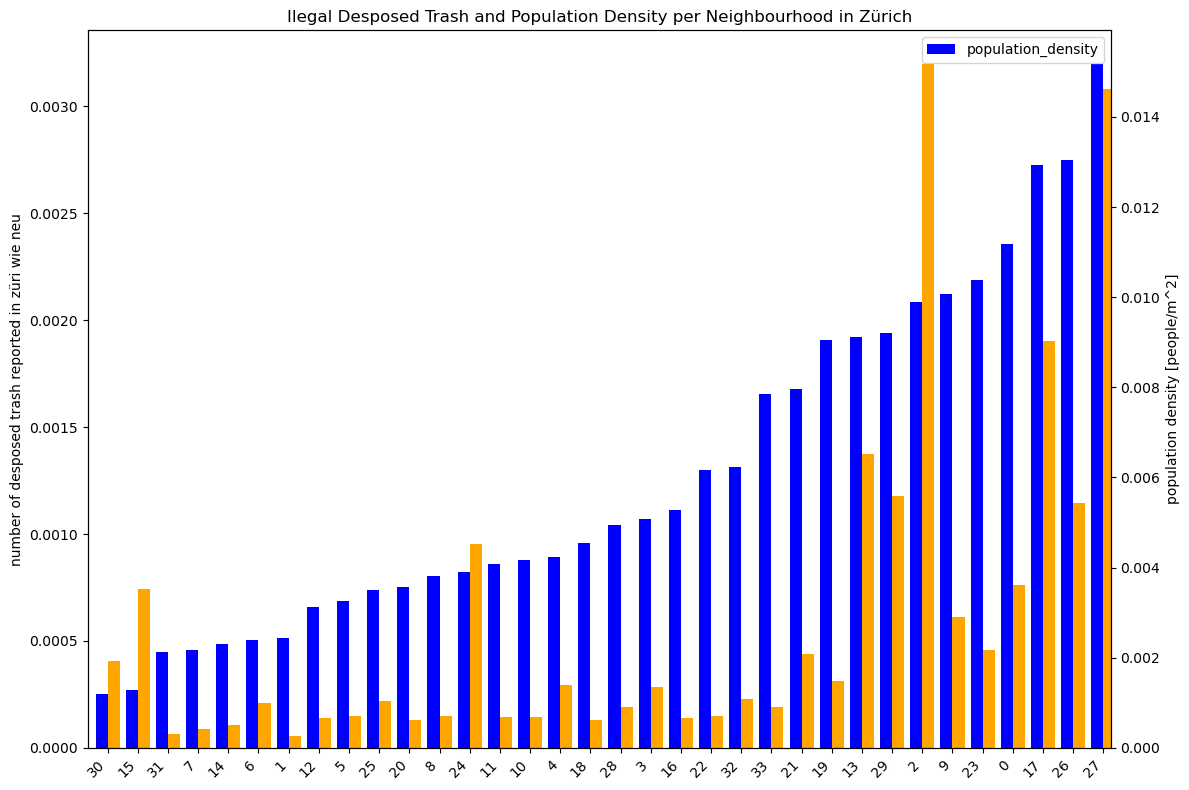

In [13]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

neighbourhood_with_popdensity_waste_gdf["waste_density"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Population Density per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
neighbourhood_with_popdensity_waste_gdf["population_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="population density [people/m^2]"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

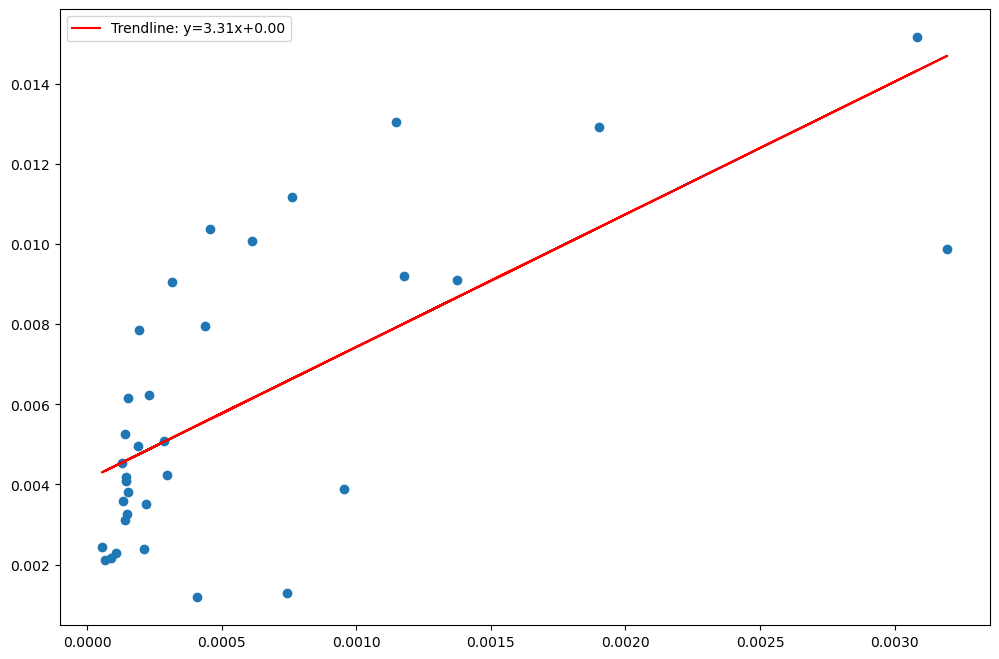

In [14]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(neighbourhood_with_popdensity_waste_gdf["waste_density"], neighbourhood_with_popdensity_waste_gdf["population_density"])
m, b = np.polyfit(neighbourhood_with_popdensity_waste_gdf["waste_density"], neighbourhood_with_popdensity_waste_gdf["population_density"], 1)
x= neighbourhood_with_popdensity_waste_gdf["waste_density"]
y= neighbourhood_with_popdensity_waste_gdf["population_density"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


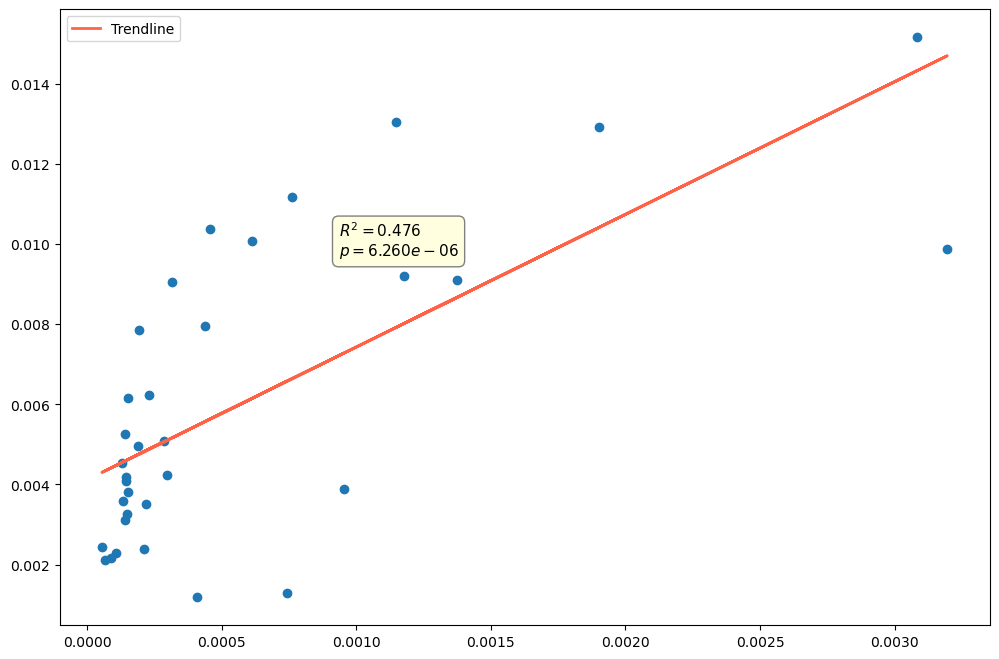

In [22]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= neighbourhood_with_popdensity_waste_gdf["waste_density"]
y= neighbourhood_with_popdensity_waste_gdf["population_density"]

ax3.scatter(x,y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='tomato', linewidth=2, label='Trendline')
x= neighbourhood_with_popdensity_waste_gdf["waste_density"]
y= neighbourhood_with_popdensity_waste_gdf["population_density"]

ax3.annotate(
    f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()